In [1]:
import numpy as np
import matplotlib.pyplot as plt


from piwavelet.plotting.coherence import (
    plot_wavelet_coherence,
)

from piwavelet.wavelets import Morlet

from piwavelet.transforms.wtc import wavelet_coherence
from piwavelet.statistics.wcsignificance import wcsignificance

In [2]:
n = 100
y1 = np.random.rand(n)
y2 = np.random.rand(n)
x = np.arange(0, n, 1)
y1 = (y1-y1.mean())/y1.std()
y2 = (y2-y2.mean())/y2.std()
coherence = wavelet_coherence(y1, y2, wavelet=Morlet(), dt=1.0)
sig = wcsignificance(y1, y2, wavelet=Morlet(), dt=1.0)
coherence.significance = sig

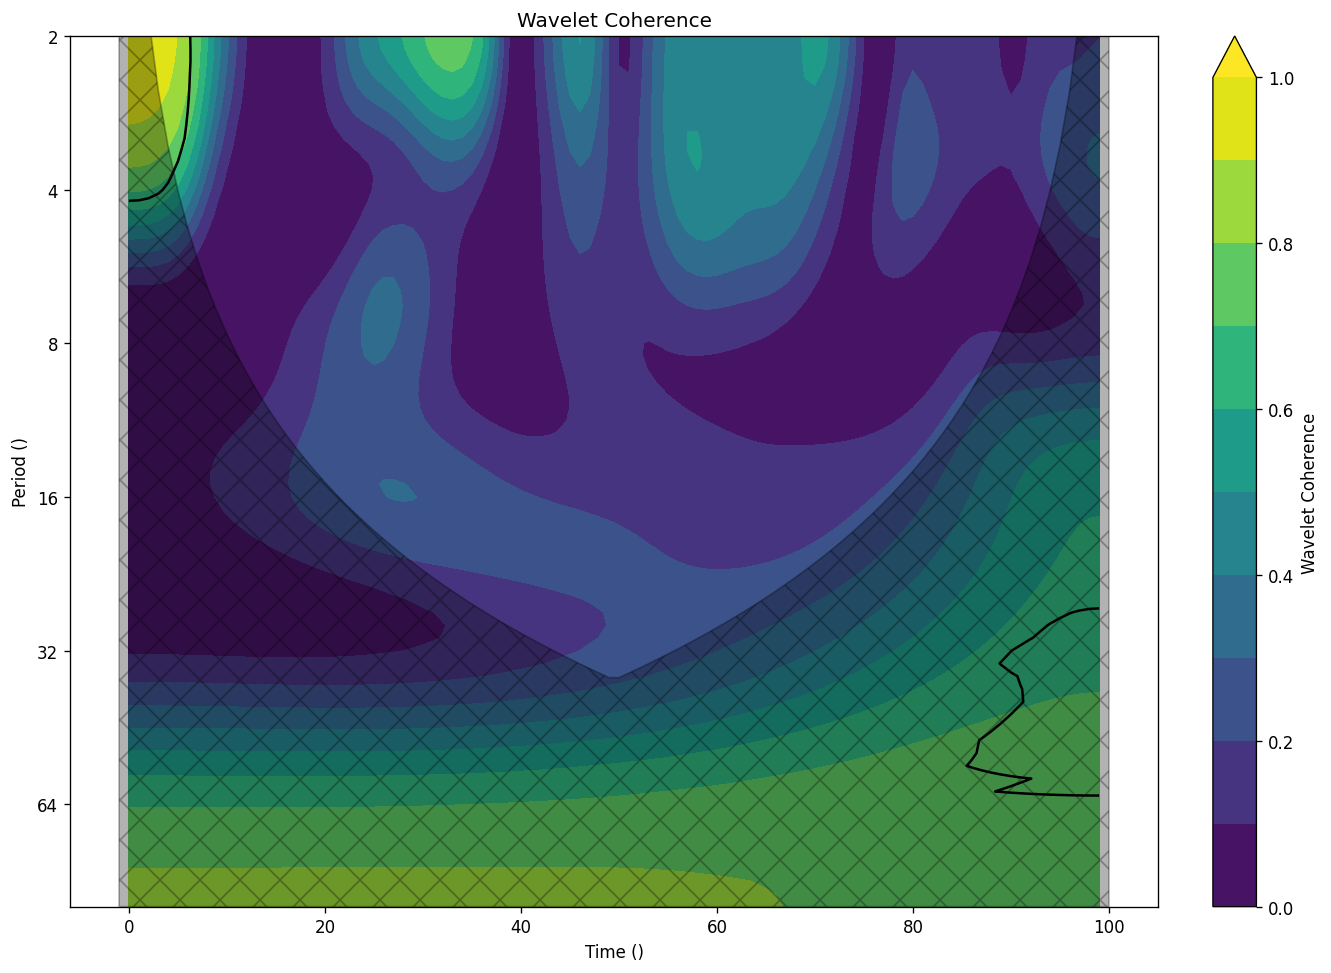

In [3]:
fig = plot_wavelet_coherence(coherence, title="Wavelet Coherence")

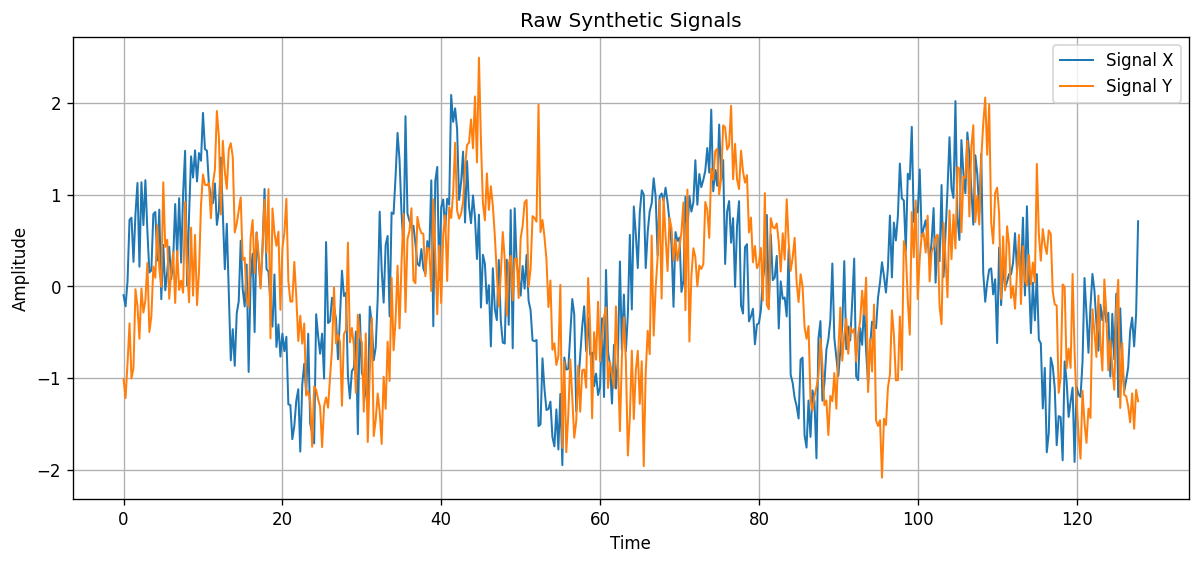

In [4]:
# ----------------------------------------------------------------------
# synthetic signal
# ----------------------------------------------------------------------

np.random.seed(42)

dt = 0.25

time = np.arange(0, 512) * dt

# sinal base (oscilação lenta + rápida)
x = (
    np.sin(2 * np.pi * time / 32)
    + 0.5 * np.sin(2 * np.pi * time / 8)
)

# sinal 2 com defasagem + ruído
y = (
    np.sin(2 * np.pi * (time - 4) / 32)
    + 0.5 * np.sin(2 * np.pi * (time - 2) / 8)
)

# ruído
y += 0.4 * np.random.randn(len(time))
x += 0.4 * np.random.randn(len(time))

# ----------------------------------------------------------------------
# raw signals plot
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 5),
    dpi=120,
)

ax.plot(
    time,
    x,
    linewidth=1.2,
    label="Signal X",
)

ax.plot(
    time,
    y,
    linewidth=1.2,
    label="Signal Y",
)

ax.set_title(
    "Raw Synthetic Signals"
)

ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")

ax.grid(True)

ax.legend()

plt.show()

In [5]:
coherence = wavelet_coherence(x, y, dt=dt, wavelet=Morlet())
sig = wcsignificance(x, y, wavelet=Morlet(), dt=1.0)
coherence.significance = sig

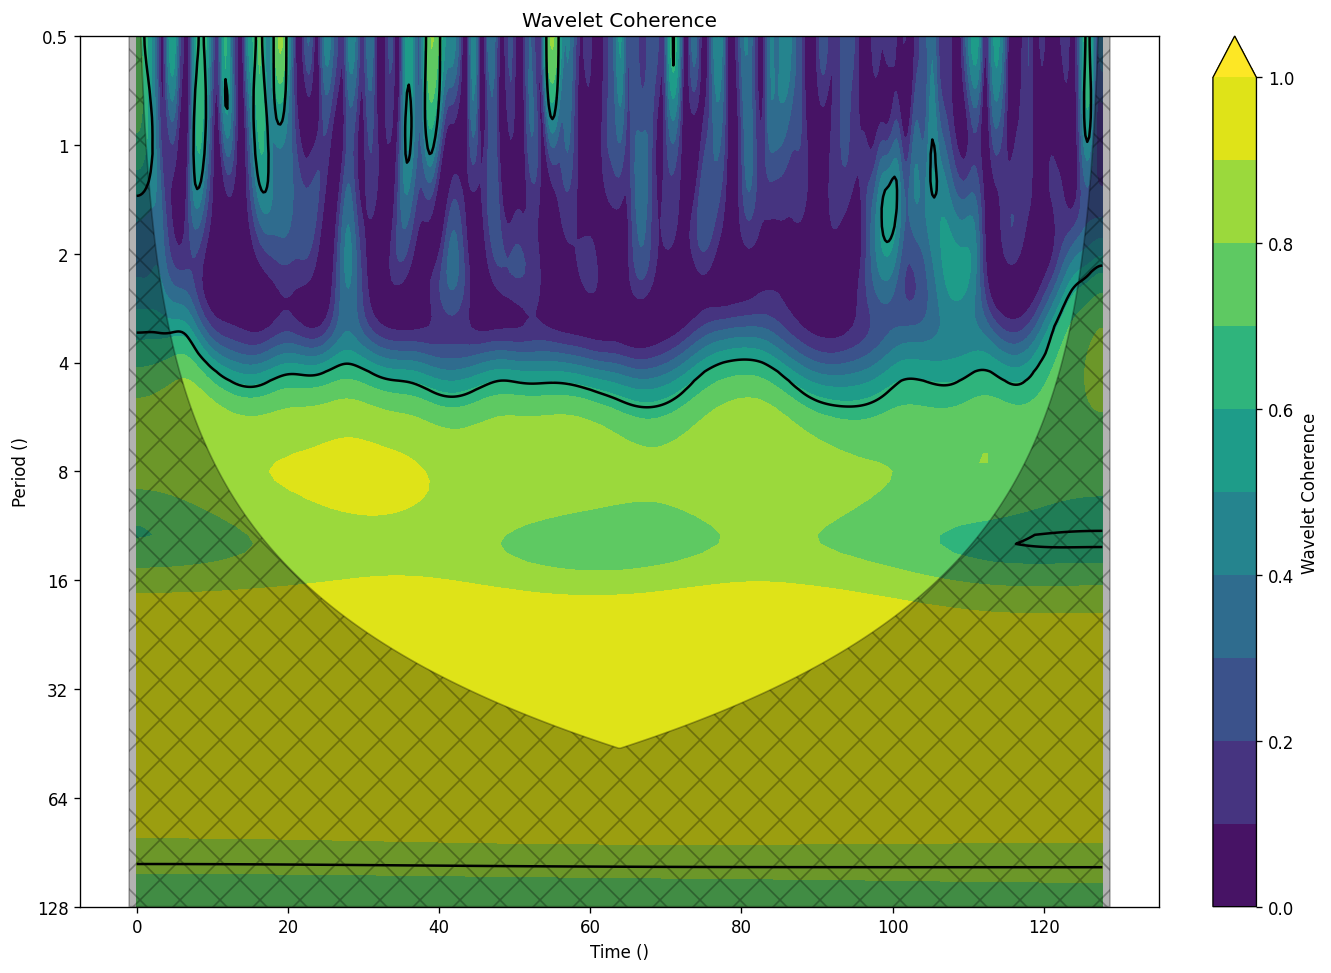

In [6]:
fig = plot_wavelet_coherence(coherence, title="Wavelet Coherence")

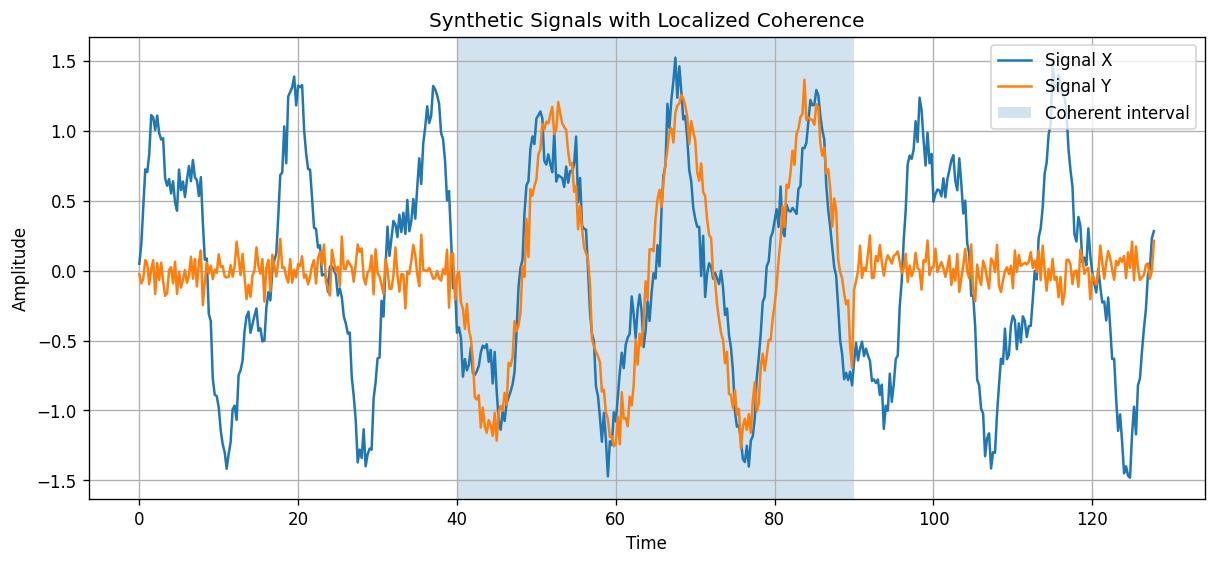

AR1EstimationError: Cannot determine unbiased AR(1) coefficient. Series may be too short or strongly trended.

In [7]:
# ----------------------------------------------------------------------
# synthetic signal
# ----------------------------------------------------------------------

np.random.seed(42)

dt = 0.25

time = np.arange(0, 512) * dt

# período alvo
period = 16

# frequência coerente
shared = np.sin(
    2 * np.pi * time / period
)

# ----------------------------------------------------------------------
# signal x
# ----------------------------------------------------------------------

# sinal contínuo
x = shared.copy()

# adiciona componente extra
x += 0.4 * np.sin(
    2 * np.pi * time / 6
)

# ruído
x += 0.1 * np.random.randn(len(time))

# ----------------------------------------------------------------------
# signal y
# ----------------------------------------------------------------------

# inicialmente apenas ruído
y = 0.1 * np.random.randn(len(time))

# janela temporal central
mask = (
    (time > 40)
    & (time < 90)
)

# adiciona coerência apenas no centro
y[mask] += shared[mask]

# pequena defasagem opcional
y[mask] += 0.2 * np.sin(
    2 * np.pi * (time[mask] - 2) / period
)

# ----------------------------------------------------------------------
# raw signals plot
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 5),
    dpi=120,
)

ax.plot(
    time,
    x,
    label="Signal X",
)

ax.plot(
    time,
    y,
    label="Signal Y",
)

# destaca região coerente
ax.axvspan(
    40,
    90,
    alpha=0.2,
    label="Coherent interval",
)

ax.set_title(
    "Synthetic Signals with Localized Coherence"
)

ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")

ax.legend()

ax.grid(True)

plt.show()

coherence = wavelet_coherence(x, y, dt=dt, wavelet=Morlet())
sig = wcsignificance(x, y, wavelet=Morlet(), dt=1.0)
coherence.significance = sig

fig = plot_wavelet_coherence(coherence, title="Wavelet Coherence", )